# Lecture 3 — Class Exercise
## Line Charts & Slopegraphs: CO2 Emissions

> **Push to:** `week03/lecture03_exercise.ipynb` in your GitHub repo

### Remember:
1. No spaghetti — multiple lines must use grey + single highlight
2. Remove clutter: no chart borders, no heavy gridlines, no legend if you can label directly
3. Insight title — states the finding, not the topic
4. Carry forward from Lecture 2: white background, Arial font, professional quality


In [5]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

# Dataset: CO2 Emissions by Country 2000-2022
# Source: Our World in Data (https://ourworldindata.org/co2-emissions)
df = pd.read_csv('../data/co2_emissions.csv')
print(f"Loaded: {len(df)} rows | Countries: {df['Country'].nunique()} | Years: {df['Year'].min()}-{df['Year'].max()}")
print(df.head())


Loaded: 345 rows | Countries: 15 | Years: 2000-2022
         Country         Region  Year  CO2_Mt  CO2_per_capita
0  United States  North America  2000  5857.6            1.32
1  United States  North America  2001  5724.0            1.26
2  United States  North America  2002  5652.8            1.11
3  United States  North America  2003  5592.8            1.29
4  United States  North America  2004  5743.2            1.12


In [6]:
# Explore before building

print("Countries:", df['Country'].unique())
print("\nCO2 range:", df['CO2_Mt'].min(), "to", df['CO2_Mt'].max(), "Mt")
print("\nRegional averages (2022):")
print(df[df['Year']==2022].groupby('Region')['CO2_Mt'].mean().sort_values(ascending=False).round(1))


Countries: ['United States' 'China' 'India' 'Germany' 'United Kingdom' 'France'
 'Brazil' 'Japan' 'Canada' 'Australia' 'South Korea' 'Russia'
 'South Africa' 'Mexico' 'Indonesia']

CO2 range: 125.3 to 12409.5 Mt

Regional averages (2022):
Region
Asia             3531.1
North America    2393.8
Latin America     629.2
Africa            534.4
Europe            496.5
Oceania           493.7
Name: CO2_Mt, dtype: float64


---
## Task 1 — Multi-Series Line Chart with Highlight

**What to build:** A line chart showing CO2 emissions over time for **all Asian countries** in the dataset, with one country highlighted.

**Requirements:**
- All countries shown (for context), but only **one highlighted in colour** — your choice which
- All other lines in grey (#DDDDDD), thinner
- Highlighted country **labelled directly** at the end of its line (not in a legend)
- Insight title that names the highlighted country and its story

> 💡 `df[df['Region'] == 'Asia']` to filter; use `go.Figure()` with a loop for per-country control


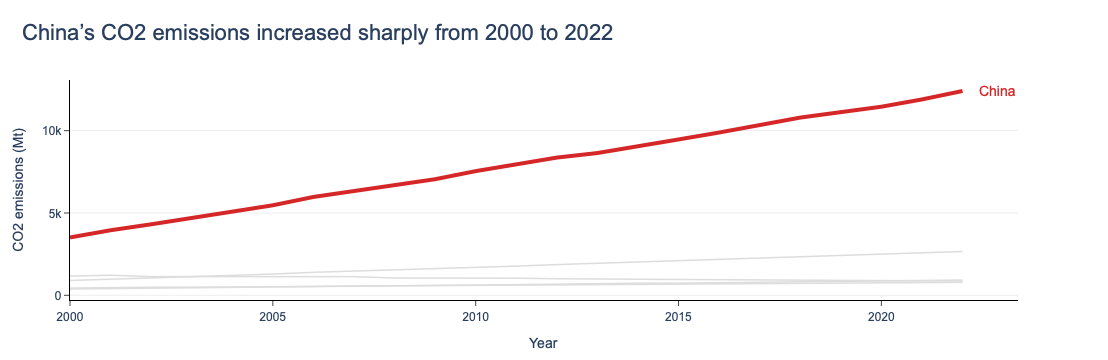

In [7]:
# Task 1 — Multi-series line with highlight
# YOUR CODE HERE
asian_df = df[df['Region'] == 'Asia']

highlight_country = "China"

fig = go.Figure()

for country in asian_df['Country'].unique():
    country_df = asian_df[asian_df['Country'] == country]
    
    is_highlight = country == highlight_country
    
    fig.add_trace(go.Scatter(
        x=country_df['Year'],
        y=country_df['CO2_Mt'],
        mode='lines',
        line=dict(
            color='#D62728' if is_highlight else '#DDDDDD',
            width=4 if is_highlight else 1.5
        ),
        hovertemplate=f"{country}<br>Year: %{{x}}<br>CO2: %{{y}} Mt<extra></extra>",
        showlegend=False
    ))

# Direct label at end of highlighted line
china_2022 = asian_df[(asian_df['Country'] == highlight_country) & (asian_df['Year'] == 2022)]

fig.add_annotation(
    x=china_2022['Year'].values[0],
    y=china_2022['CO2_Mt'].values[0],
    text=highlight_country,
    showarrow=False,
    xshift=35,
    font=dict(size=14, color='#D62728', family='Arial')
)

fig.update_layout(
    title=dict(
        text="China’s CO2 emissions increased sharply from 2000 to 2022",
        font=dict(size=22, family='Arial'),
        x=0.02
    ),
    xaxis_title="Year",
    yaxis_title="CO2 emissions (Mt)",
    font=dict(family='Arial'),
    plot_bgcolor='white',
    paper_bgcolor='white',
    showlegend=False,
    margin=dict(l=70, r=90, t=80, b=60)
)

fig.update_xaxes(
    showgrid=False,
    showline=True,
    linecolor='black',
    ticks='outside'
)

fig.update_yaxes(
    showgrid=True,
    gridcolor='#EEEEEE',
    zeroline=False,
    showline=True,
    linecolor='black',
    ticks='outside'
)

fig.show()


---
## Task 2 — Slopegraph: Regional Change 2000 vs 2022

**What to build:** A slopegraph comparing **average regional CO2 emissions** between 2000 and 2022.

**Requirements:**
- One line per region (not per country — aggregate first)
- Colour: regions that increased = one colour; decreased = another
- Values labelled at both ends of each line
- No y-axis tick labels (the endpoint labels make them redundant)
- Insight title stating which regions moved most

> 💡 `df.groupby(['Region','Year'])['CO2_Mt'].mean().reset_index()` then filter to 2000 and 2022


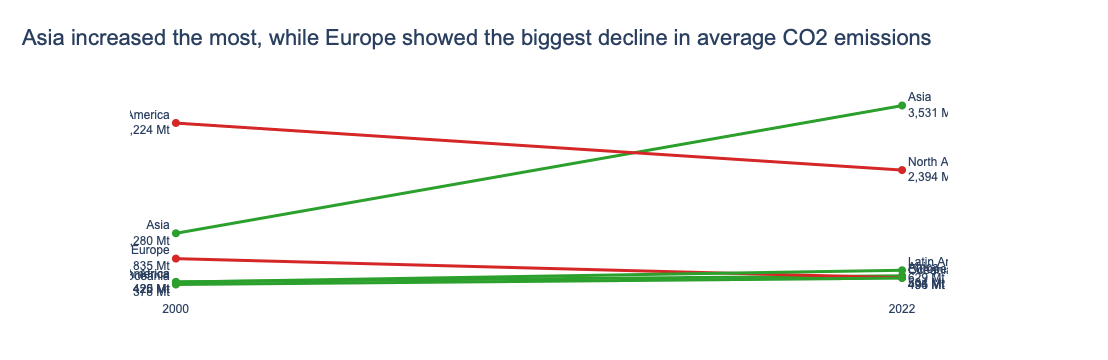

In [8]:
# Task 2 — Slopegraph: regional averages
# YOUR CODE HERE
# Aggregate average CO2 emissions by region and year
regional_avg = df.groupby(['Region', 'Year'])['CO2_Mt'].mean().reset_index()

# Keep only 2000 and 2022
slope_df = regional_avg[regional_avg['Year'].isin([2000, 2022])]

# Pivot to compare change
slope_wide = slope_df.pivot(index='Region', columns='Year', values='CO2_Mt').reset_index()
slope_wide['Change'] = slope_wide[2022] - slope_wide[2000]

fig = go.Figure()

for _, row in slope_wide.iterrows():
    increased = row['Change'] > 0
    
    fig.add_trace(go.Scatter(
        x=[2000, 2022],
        y=[row[2000], row[2022]],
        mode='lines+markers+text',
        line=dict(
            color='#2CA02C' if increased else '#D62728',
            width=3
        ),
        marker=dict(size=8),
        text=[
            f"{row['Region']}<br>{row[2000]:,.0f} Mt",
            f"{row['Region']}<br>{row[2022]:,.0f} Mt"
        ],
        textposition=['middle left', 'middle right'],
        hovertemplate=f"{row['Region']}<br>CO2: %{{y:,.0f}} Mt<extra></extra>",
        showlegend=False
    ))

fig.update_layout(
    title=dict(
        text="Asia increased the most, while Europe showed the biggest decline in average CO2 emissions",
        font=dict(size=22, family='Arial'),
        x=0.02
    ),
    xaxis=dict(
        tickmode='array',
        tickvals=[2000, 2022],
        ticktext=['2000', '2022'],
        showgrid=False,
        showline=False
    ),
    yaxis=dict(
        showticklabels=False,
        showgrid=False,
        zeroline=False,
        showline=False
    ),
    font=dict(family='Arial'),
    plot_bgcolor='white',
    paper_bgcolor='white',
    margin=dict(l=130, r=160, t=90, b=60),
    showlegend=False
)

fig.show()